# Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/Worksheet in Case Study question 2.xlsx')

# Initial Inspection

In [ ]:
df.shape

(1000, 39)

In [ ]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

# Duplicate Check

In [ ]:
df.duplicated().sum()

np.int64(0)

# Missing Values & Categorical Scan

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [ ]:
cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    print("\n", c)
    print("unique:", df[c].nunique(dropna=False))
    print(df[c].value_counts(dropna=False).head(5))


 policy_state
unique: 3
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

 policy_csl
unique: 3
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64

 insured_sex
unique: 2
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64

 insured_education_level
unique: 7
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
Name: count, dtype: int64

 insured_occupation
unique: 14
insured_occupation
machine-op-inspct    93
prof-specialty       85
tech-support         78
sales                76
exec-managerial      76
Name: count, dtype: int64

 insured_hobbies
unique: 20
insured_hobbies
reading           64
exercise          57
paintball         57
bungie-jumping    56
movies            55
Name: count, dtype: int64

 insured_relationship
unique: 6
insured_relationship
own-child         183
other-relative    177
not-in-family     174
husband           170
wife        

# Data Cleaning

In [ ]:
df = df.replace({"?": np.nan})

In [ ]:
for c in cat_cols:
    df[c] = df[c].fillna("Unknown")

In [ ]:
id_like = ["policy_number", "insured_zip"]
for c in id_like:
    df[c] = df[c].astype(str)

In [ ]:
date_cols = ["policy_bind_date", "incident_date"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

In [ ]:
incident_before_policy = df["incident_date"] < df["policy_bind_date"]
incident_before_policy.sum()

np.int64(1)

In [ ]:
df = df.loc[~incident_before_policy]
df.reset_index(drop=True, inplace=True)

In [ ]:
diff = df["total_claim_amount"] - (df["injury_claim"] + df["property_claim"] + df["vehicle_claim"])
print("Claim mismatch rows:", (diff != 0).sum())

Claim mismatch rows: 0


In [ ]:
for c in cat_cols:
    df[c] = (df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True))

In [ ]:
format_cols = ["insured_sex", "property_damage", "police_report_available", "fraud_reported", "insured_occupation", "insured_hobbies", "insured_relationship"]
for c in format_cols:
    df[c] = df[c].str.title()

# Class Balance (fraud vs non-fraud)

In [ ]:
df["fraud_reported"].value_counts(normalize=True)

,proportion
fraud_reported,
N,0.752753
Y,0.247247


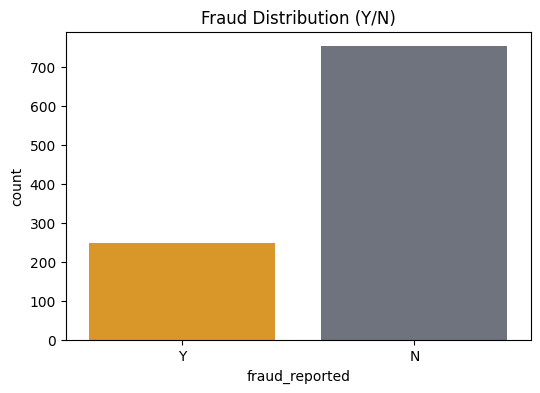

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="fraud_reported", hue="fraud_reported", palette={"N":"#6b7280", "Y":"#f59e0b"}, legend=False)
plt.title("Fraud Distribution (Y/N)")
plt.show()

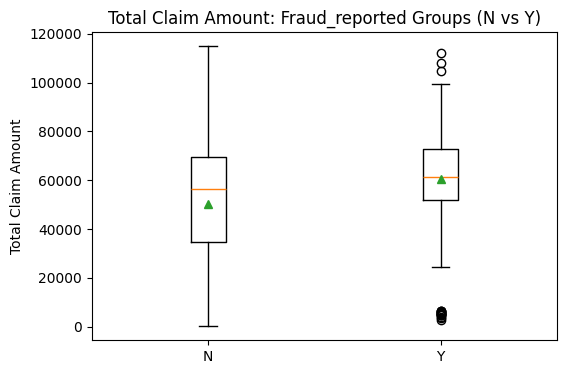

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot([n, y], tick_labels=["N", "Y"], showmeans=True)
plt.title("Total Claim Amount: Fraud_reported Groups (N vs Y)")
plt.ylabel("Total Claim Amount")
plt.show()

# Hypothesis Testing

In [ ]:
from scipy import stats

# h0: The mean of total_claim_amount is the same for the fraud_reported = y and fraud_reported = n groups.
# h1: the mean of total_claim_amount is different between the fraud_reported = y and fraud_reported = n groups.

y = df[df["fraud_reported"] == "Y"]["total_claim_amount"]
n = df[df["fraud_reported"] == "N"]["total_claim_amount"]

t_stat, p_value = stats.ttest_ind(y, n)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05
if p_value <= alpha:
    print("h0 is rejected")
else:
    print("h0 is not rejected")

t-statistic: 5.2376628930151545
p-value: 1.9836916368172926e-07
h0 is rejected


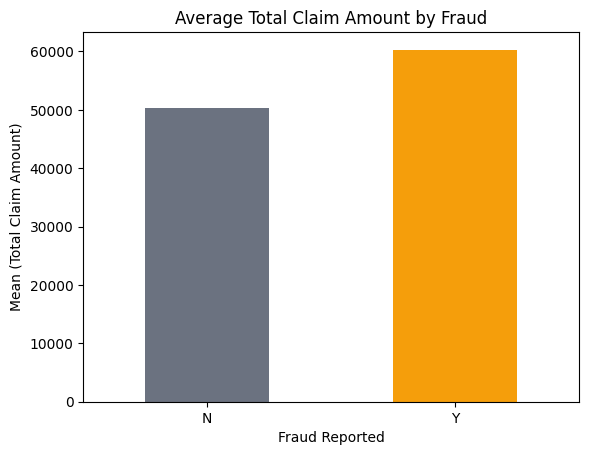

In [ ]:
mean_claim = df.groupby("fraud_reported")["total_claim_amount"].mean().sort_index()

mean_claim.plot(kind="bar", color=["#6b7280", "#f59e0b"])
plt.title("Average Total Claim Amount by Fraud")
plt.xlabel("Fraud Reported")
plt.ylabel("Mean (Total Claim Amount)")
plt.xticks(rotation=0)
plt.show()

# Correlations and Distribution Shape

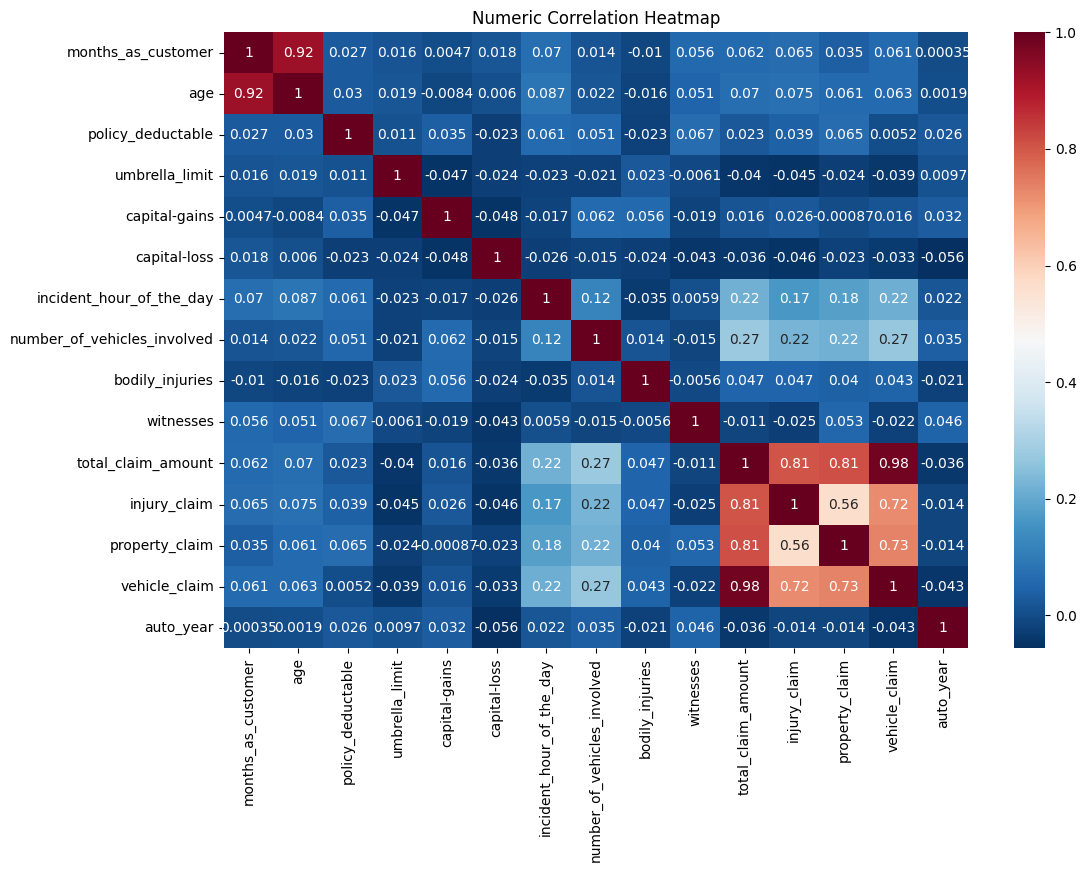

In [ ]:
numeric_df = df.select_dtypes(include='int64')

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="RdBu_r")
plt.title("Numeric Correlation Heatmap")
plt.show()

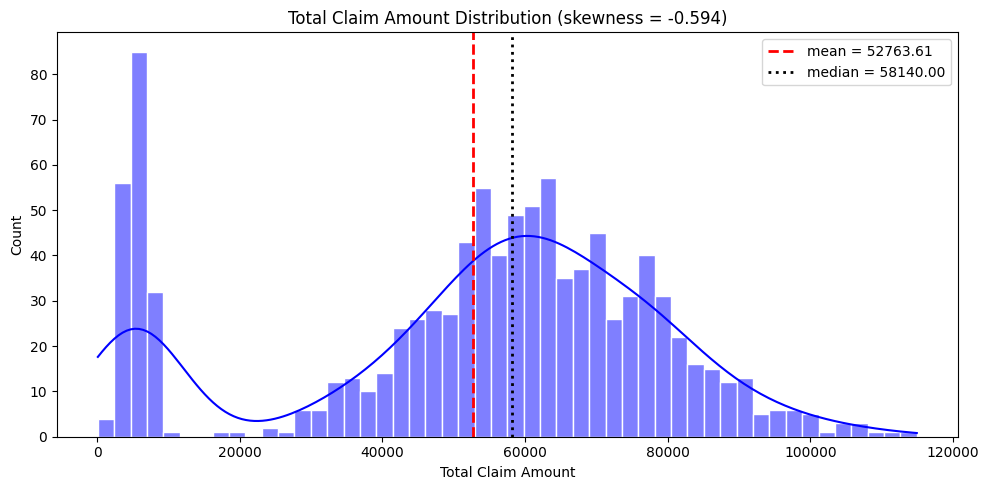

In [ ]:
col = "total_claim_amount"
x = df[col].dropna()
skew_val = x.skew()

plt.figure(figsize=(10,5))
sns.histplot(x, kde=True, color="blue", bins=50, edgecolor="white")
plt.axvline(x.mean(), color="red", linestyle="--", linewidth=2, label=f"mean = {x.mean():.2f}")
plt.axvline(x.median(), color="black", linestyle=":", linewidth=2, label=f"median = {x.median():.2f}")

plt.title(f"Total Claim Amount Distribution (skewness = {skew_val:.3f})")
plt.xlabel("Total Claim Amount")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# Export

In [ ]:
df.to_csv("cleaned_data_powerbi.csv", index=False)